# Week 4: Continuous-Time Finance


## 1. The Starting Point: Discrete Random Walk

### Building Blocks

Consider a sequence of IID (Independent and Identically Distributed) random variables $z_1, z_2, \dots, z_n$. These represent **elementary shocks** — think of them as the outcome of flipping a fair coin at each time step.

Their defining properties are:
- **Zero Mean:** $\mathbb{E}[z_t] = 0$ — shocks are unbiased
- **Unit Variance:** $\text{Var}(z_t) = 1$ — each shock has a standardized size
- **No Serial Correlation:** $\text{Cov}(z_t, z_s) = \delta_{ts}$ — past shocks carry no information about future ones

### Summing the Shocks

We define the basic random walk $B_{1,T}$ as the sum of all shocks from time 0 to time $T$ (where each step has size $\Delta t = 1$):

$$B_{1,T} = \sum_{t=t_0+1}^{t_0+T} z_t$$

From the properties of IID variables:

$$\mathbb{E}_t[B_{1,T}] = 0 \quad \text{(zero expected value)}$$

$$\text{Var}_t(B_{1,T}) = T \quad \text{(variance grows linearly with time)}$$

The variance is additive: summing $T$ independent shocks each of variance 1 gives total variance $T$. This is the **hallmark of diffusion** — uncertainty grows as $\sqrt{T}$, not linearly.

### Key Structural Properties

The random walk also has two important structural symmetries:

1. **Time-translation invariance:** The distribution of $B_{1,T'} - B_{1,T}$ depends only on the elapsed time $T' - T$, not on where you start in time.

2. **Conditional variance:** As information accrues, the remaining uncertainty shrinks:
$$\text{Var}_{t_1}(B_{1,T}) = T - (t_1 - t_0), \quad t_0 \leq t_1 \leq T$$

These properties survive the passage to continuous time and become the defining axioms of **Brownian motion**.

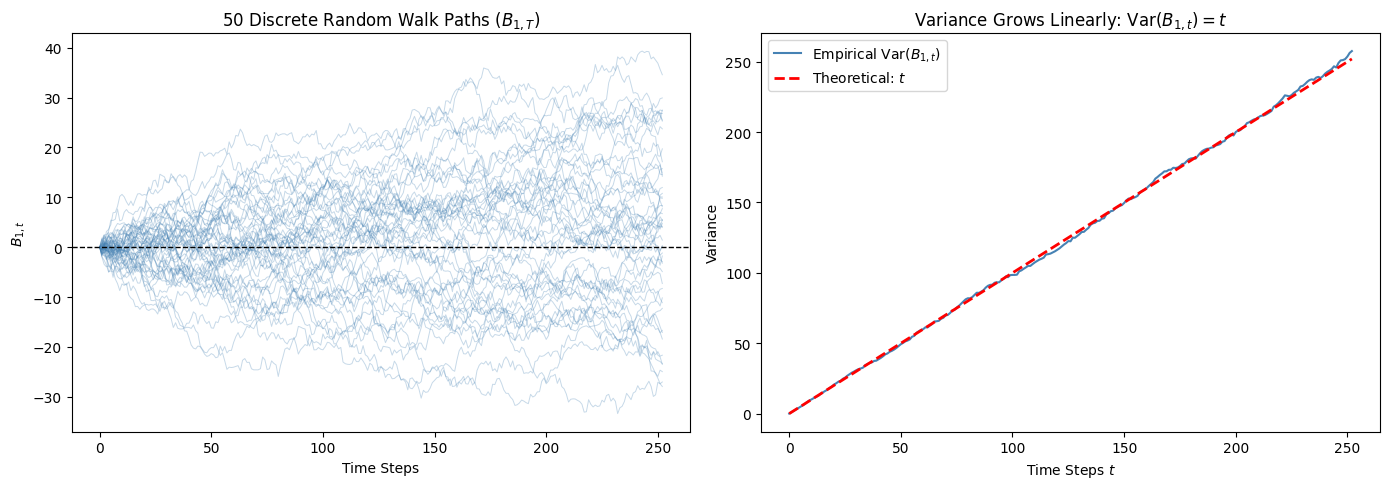

Theoretical variance at T=252: 252
Empirical variance at T=252:   257.60


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

# Simulate discrete random walks: sum of iid z_t ~ N(0,1)
T = 252       # number of steps (one trading year)
N = 1000      # number of paths

z = np.random.randn(T, N)           # iid shocks
B = np.vstack([np.zeros(N), np.cumsum(z, axis=0)])  # cumulative sum = random walk

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample paths
for i in range(50):
    axes[0].plot(B[:, i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set(title='50 Discrete Random Walk Paths ($B_{1,T}$)',
            xlabel='Time Steps', ylabel='$B_{1,t}$')

# Right: variance grows linearly with T
t_vals = np.arange(T + 1)
empirical_var = np.var(B, axis=1)
axes[1].plot(t_vals, empirical_var, label='Empirical Var$(B_{1,t})$', color='steelblue')
axes[1].plot(t_vals, t_vals, 'r--', label='Theoretical: $t$', linewidth=2)
axes[1].set(title='Variance Grows Linearly: Var$(B_{1,t}) = t$',
            xlabel='Time Steps $t$', ylabel='Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical variance at T={T}: {T}")
print(f"Empirical variance at T={T}:   {empirical_var[-1]:.2f}")

## 2. The Scaling Dilemma

### The Question

We want to **subdivide the time interval** $[0, T]$ into $n$ smaller steps of size $\Delta t = T/n$, while **preserving the distribution of terminal values**. As $n \to \infty$, we want a well-defined continuous-time limit.

The question is: **how should we scale the individual shocks $\epsilon_t$ as $n$ grows?**

Since the shocks are independent, the total variance of the walk is:

$$\text{Var}(B_{\Delta t, T}) = \sum_{t=1}^{n} \text{Var}(\epsilon_t) = n \cdot \text{Var}(\epsilon_t)$$

There are three natural choices, each with a drastically different outcome.

### Case I: No Rescaling — The Exploding Limit

**Setup:** Simply divide the time interval but keep each shock at full unit size: $\epsilon_t = z_t$.

$$B_{\Delta t, T} \equiv \sum_{t=1}^{n} z_t, \qquad \text{where } \Delta t = T/n$$

**What happens to the variance?**

Each $z_t$ still has $\text{Var}(z_t) = 1$, so:

$$\text{Var}(B_{\Delta t, T}) = n \cdot \text{Var}(z_t) = n$$

$$\lim_{n \to \infty} \text{Var}(B_{\Delta t, T}) = \infty$$

**Intuition:** You are adding more and more unit-sized coin flips. Even though each step covers a shorter time interval, each shock still has the same magnitude. The accumulated noise diverges. The process becomes infinitely volatile — paths explode in all directions.

**Financial implication:** An asset following this process would have infinite variance over any fixed horizon. That's physically and economically meaningless — no price process can behave this way.

> **Key takeaway:** Subdividing time without shrinking the shocks breaks the model.

### Case II: Linear Rescaling — The Vanishing Limit

**Setup:** Scale each shock proportionally to the number of steps: $\epsilon_t = \lambda z_t$, with $\lambda = 1/n \to 0$.

$$B_{\Delta t, T} = \sum_{t=1}^{n} \epsilon_t = \lambda \sum_{t=1}^{n} z_t$$

**What happens to the variance?**

$$\text{Var}(B_{\Delta t, T}) = n \cdot \text{Var}(\lambda z_t) = n \cdot \lambda^2 = n \cdot \frac{1}{n^2} = \frac{1}{n}$$

$$\lim_{n \to \infty} \text{Var}(B_{\Delta t, T}) = 0$$

**Intuition:** Now you are shrinking the shocks too aggressively. Each individual step becomes so tiny that the total accumulated noise vanishes entirely. As $n \to \infty$, the process converges to a **deterministic flat line at zero** — all randomness disappears.

**Financial implication:** An asset with no volatility has a known, deterministic price path. That's also meaningless as a model for risky assets.

> **Key takeaway:** Over-shrinking the shocks destroys all randomness. We need the "Goldilocks" scaling in between.

### Case III: Square-Root Scaling — The Brownian Limit ✓

**Setup:** Scale each shock by $\sqrt{\Delta t}$: $\epsilon_t = \sqrt{\Delta t} \cdot z_t$. Since $\Delta t = T/n$:

$$B_{\Delta t, T} = \sum_{t=1}^{n} \epsilon_t = \sqrt{\Delta t} \sum_{t=1}^{n} z_t$$

**What happens to the variance?**

$$\text{Var}(\epsilon_t) = \Delta t \cdot \text{Var}(z_t) = \frac{T}{n}$$

$$\text{Var}(B_{\Delta t, T}) = n \cdot \frac{T}{n} = T$$

$$\lim_{\Delta t \to 0} B_{\Delta t, T} \sim \mathcal{N}(0, T)$$

**Intuition:** This is the "Goldilocks" scaling. You are subdividing time AND shrinking the steps in precisely the right proportion so that the **total accumulated variance stays equal to $T$** — regardless of how fine the grid is. The $n$ factors cancel perfectly.

**Why $\sqrt{\Delta t}$ specifically?** Because variance is additive (not standard deviation), and adding $n$ terms of size $\Delta t$ gives $n \cdot \Delta t = T$. Standard deviation scales as $\sqrt{T}$, which is the famous square-root-of-time rule for diffusion.

**Formal limit (Central Limit Theorem):** By the CLT, the sum of many small IID random variables converges in distribution to a Gaussian. Specifically:

$$B_{\Delta t, T} = \sqrt{\Delta t} \sum_{t=1}^{n} z_t \xrightarrow{d} \mathcal{N}(0, T) \quad \text{as } \Delta t \to 0$$

This limit is **Standard Brownian Motion** (also called a Wiener Process).

> **Key takeaway:** The $\sqrt{\Delta t}$ scaling is the *unique* choice that preserves a finite, nonzero variance in the continuum limit. This is not a modeling assumption — it's forced by the requirement that the limit exists.

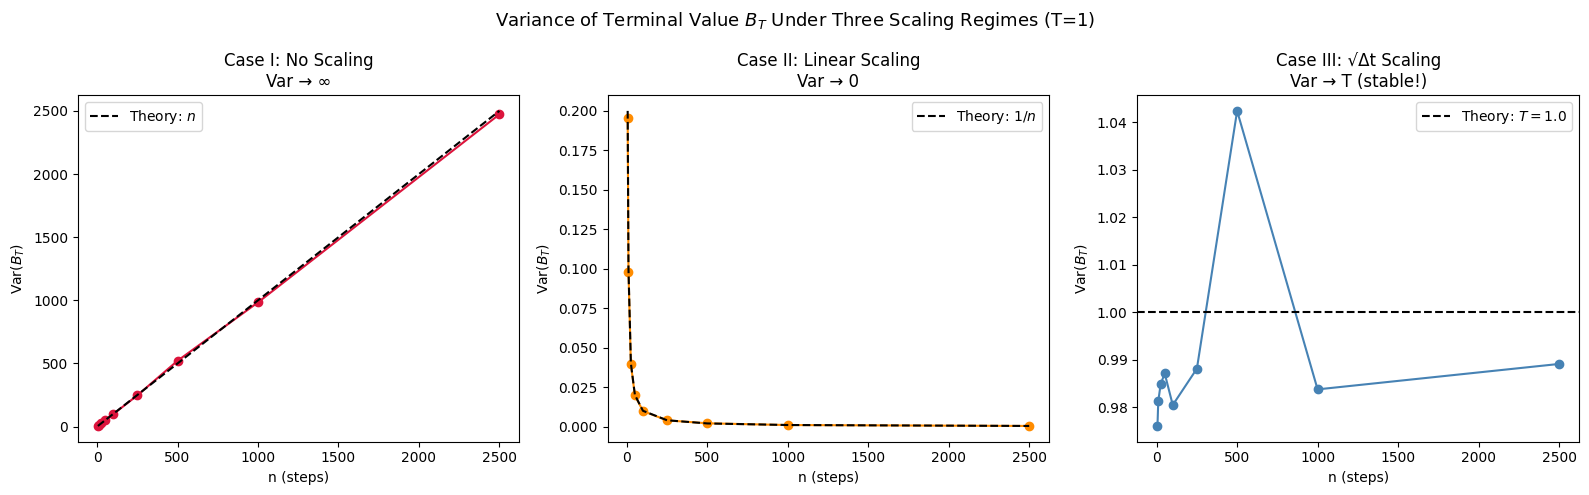

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 1.0
Np = 5000   # simulations per n value
n_values = [5, 10, 25, 50, 100, 250, 500, 1000, 2500]

var_case1, var_case2, var_case3 = [], [], []

for n in n_values:
    dt = T / n
    z = np.random.randn(n, Np)         # iid N(0,1) shocks

    # Case I: no rescaling — epsilon = z
    B1_T = z.sum(axis=0)
    var_case1.append(np.var(B1_T))

    # Case II: linear rescaling — epsilon = (1/n)*z
    B2_T = (z / n).sum(axis=0)
    var_case2.append(np.var(B2_T))

    # Case III: sqrt(dt) rescaling — epsilon = sqrt(dt)*z
    B3_T = (np.sqrt(dt) * z).sum(axis=0)
    var_case3.append(np.var(B3_T))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(n_values, var_case1, 'o-', color='crimson')
axes[0].plot(n_values, n_values, 'k--', label='Theory: $n$')
axes[0].set(title='Case I: No Scaling\nVar → ∞', xlabel='n (steps)', ylabel='Var($B_T$)')
axes[0].legend()

axes[1].plot(n_values, var_case2, 'o-', color='darkorange')
axes[1].plot(n_values, [1/n for n in n_values], 'k--', label='Theory: $1/n$')
axes[1].set(title='Case II: Linear Scaling\nVar → 0', xlabel='n (steps)', ylabel='Var($B_T$)')
axes[1].legend()

axes[2].plot(n_values, var_case3, 'o-', color='steelblue')
axes[2].axhline(T, color='k', linestyle='--', label=f'Theory: $T={T}$')
axes[2].set(title='Case III: √Δt Scaling\nVar → T (stable!)', xlabel='n (steps)', ylabel='Var($B_T$)')
axes[2].legend()

plt.suptitle('Variance of Terminal Value $B_T$ Under Three Scaling Regimes (T=1)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Standard Brownian Motion $W_t$

### Formal Definition

Standard Brownian Motion (also called a **Wiener Process**) $W_t$ is the continuous-time limit of the Case III scaled random walk. It is defined by three axioms:

1. **$W_0 = 0$:** The process starts at zero.
2. **Independent Increments:** For $s < t$, the increment $W_t - W_s$ is independent of $\mathcal{F}_s$ (the history up to time $s$).
3. **Stationary Gaussian Increments:** 
$$W_t - W_s \sim \mathcal{N}(0,\, t-s) \quad \text{for all } s < t$$

These axioms encode the essential properties we derived from the discrete random walk. The variance of an increment equals the elapsed time — this is the key.

### The "Nowhere Differentiable" Paradox

Brownian paths are **continuous everywhere but differentiable nowhere**. This sounds paradoxical but follows directly from the scaling. Consider the "velocity" over a small interval:

$$\frac{\Delta W}{\Delta t} \approx \frac{\sqrt{\Delta t} \cdot z_t}{\Delta t} = \frac{z_t}{\sqrt{\Delta t}} \xrightarrow[\Delta t \to 0]{} \infty$$

The ratio diverges as $\Delta t \to 0$. You can't define a finite derivative — the path is too jagged at every scale. This is why we need a new calculus (**Itô calculus**) and write $dW_t$ rather than $dW_t/dt$.

### The Infinitesimal Limit

Once we have Brownian motion, we can treat the infinitesimal increment $dB_t$ as the fundamental building block, analogous to the unit-step $z_t$ in the discrete walk:

$$dB_t \sim \mathcal{N}(0,\, dt)$$

$$\text{Cov}(dB_t,\, dB_{t'}) = \begin{cases} dt & t = t' \\ 0 & t \neq t' \end{cases}$$

And the full Brownian path is recovered by integration:

$$B(T) = B(0) + \int_0^T dB_t$$

This is the **Riemann sum in the limit**: the continuous path is constructed by summing infinitely many infinitesimal Gaussian shocks. Whenever you see $\sigma dB_t$ in an SDE, you are adding a random shock of magnitude $\sigma\sqrt{dt}$ at each instant.

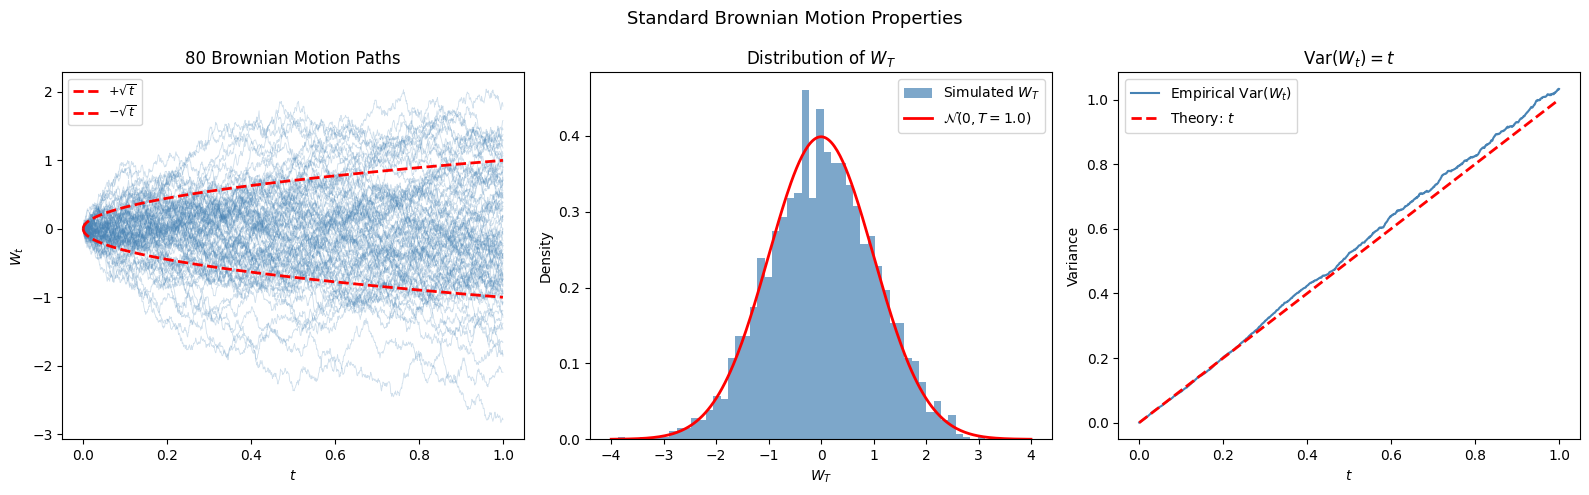

In [5]:
"""
Brownian motion paths and distributional properties.
"""
np.random.seed(7)

T = 1.0
n = 1000      # fine time grid
dt = T / n
t_grid = np.linspace(0, T, n + 1)
Np = 2000

# Simulate Brownian motion paths via Case III scaling
dW = np.sqrt(dt) * np.random.randn(n, Np)
W = np.vstack([np.zeros(Np), np.cumsum(dW, axis=0)])

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# -- Panel 1: sample paths
ax1 = fig.add_subplot(gs[0])
for i in range(80):
    ax1.plot(t_grid, W[:, i], alpha=0.25, linewidth=0.6, color='steelblue')
ax1.plot(t_grid, np.sqrt(t_grid), 'r--', linewidth=2, label='$+\\sqrt{t}$')
ax1.plot(t_grid, -np.sqrt(t_grid), 'r--', linewidth=2, label='$-\\sqrt{t}$')
ax1.set(title='80 Brownian Motion Paths', xlabel='$t$', ylabel='$W_t$')
ax1.legend(fontsize=9)

# -- Panel 2: distribution of W_T is N(0, T)
ax2 = fig.add_subplot(gs[1])
W_T = W[-1, :]
ax2.hist(W_T, bins=50, density=True, color='steelblue', alpha=0.7, label='Simulated $W_T$')
x = np.linspace(-4, 4, 300)
ax2.plot(x, (1/np.sqrt(2*np.pi*T)) * np.exp(-x**2 / (2*T)),
         'r-', linewidth=2, label=f'$\\mathcal{{N}}(0,T={T})$')
ax2.set(title='Distribution of $W_T$', xlabel='$W_T$', ylabel='Density')
ax2.legend()

# -- Panel 3: variance grows linearly in t
ax3 = fig.add_subplot(gs[2])
emp_var = np.var(W, axis=1)
ax3.plot(t_grid, emp_var, color='steelblue', label='Empirical Var$(W_t)$')
ax3.plot(t_grid, t_grid, 'r--', linewidth=2, label='Theory: $t$')
ax3.set(title='Var$(W_t) = t$', xlabel='$t$', ylabel='Variance')
ax3.legend()

plt.suptitle('Standard Brownian Motion Properties', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Scales for Drift and Volatility: The Log-Return Model

### Why Log-Returns?

In finance, we model **log-returns** rather than price levels. The key reason is that stock prices cannot be negative. If $\log(S_t/S_{t-1}) \sim \mathcal{N}(\mu_0, \sigma_0^2)$, then $S_t > 0$ always, and cumulative returns over many periods are normally distributed (by the CLT).

Starting from the discrete model at $\Delta t = 1$:

$$r_t = \log\!\left(\frac{S_t}{S_{t-1}}\right) = \mu_0 + \sigma_0 z_t \sim \mathcal{N}(\mu_0, \sigma_0^2)$$

Summing over $T$ periods:

$$\log\!\left(\frac{S_T}{S_0}\right) = \sum_{t=1}^{T} r_t \sim \mathcal{N}(\mu_0 T,\, \sigma_0^2 T)$$

### Taking the Continuous-Time Limit

Now subdivide the interval into $T/\Delta t$ steps, holding the **annualized** drift $\mu$ and volatility $\sigma$ fixed as $\Delta t \to 0$:

$$\log\!\left(\frac{S_T}{S_0}\right) = \lim_{\Delta t \to 0} \left[\sum_{t=1}^{T/\Delta t} \mu \Delta t + \sum_{t=1}^{T/\Delta t} \sigma z_t \sqrt{\Delta t}\right] = \mu T + \sigma \int_0^T dB_t \sim \mathcal{N}(\mu T,\, \sigma^2 T)$$

This is **Geometric Brownian Motion (GBM)**. In differential form:

$$\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dB_t \qquad \Longleftrightarrow \qquad dS_t = \mu S_t\, dt + \sigma S_t\, dB_t$$

The solution is:

$$S_T = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma B_T\right]$$

### The $-\sigma^2/2$ Itô Correction

Notice that the drift in the exponent is **$\mu - \sigma^2/2$**, not $\mu$. This correction arises from Itô's lemma (covered next) and is a purely mathematical consequence of the non-differentiability of Brownian motion. It ensures:

$$\mathbb{E}[S_T] = S_0 e^{\mu T}$$

(the expected price grows at rate $\mu$), while the **median** price is $S_0 e^{(\mu - \sigma^2/2)T}$ — always below the mean due to Jensen's inequality for the lognormal.

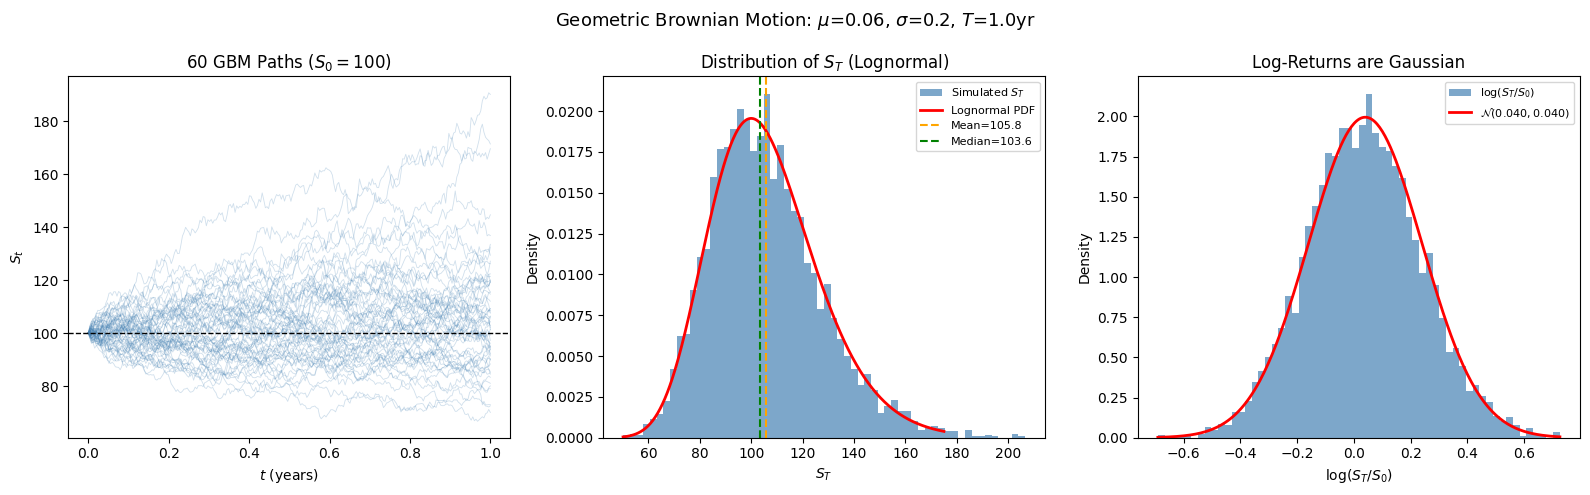

Theoretical E[S_T] = S0·exp(μT) = 106.18
Simulated  E[S_T]              = 105.80
Theoretical median(S_T)        = 104.08
Simulated  median(S_T)         = 103.60


In [15]:
"""
Simulate Geometric Brownian Motion paths and verify the lognormal distribution.
"""
np.random.seed(13)

S0, mu, sigma, T_gbm = 100, 0.06, 0.20, 1.0
n_steps = 252
dt_gbm = T_gbm / n_steps
Np_gbm = 5000
t_g = np.linspace(0, T_gbm, n_steps + 1)

# Simulate log-returns and compound them
dlog = (mu - 0.5 * sigma**2) * dt_gbm + sigma * np.sqrt(dt_gbm) * np.random.randn(n_steps, Np_gbm)
log_S = np.vstack([np.zeros(Np_gbm), np.cumsum(dlog, axis=0)])
S_paths = S0 * np.exp(log_S)

S_T = S_paths[-1, :]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: sample paths
for i in range(60):
    axes[0].plot(t_g, S_paths[:, i], alpha=0.25, linewidth=0.6, color='steelblue')
axes[0].axhline(S0, color='black', linestyle='--', linewidth=1)
axes[0].set(title='60 GBM Paths ($S_0=100$)', xlabel='$t$ (years)', ylabel='$S_t$')

# Panel 2: distribution of S_T (lognormal)
axes[1].hist(S_T, bins=60, density=True, color='steelblue', alpha=0.7, label='Simulated $S_T$')
x_ln = np.linspace(S_T.min(), np.percentile(S_T, 99.5), 400)
log_mean = np.log(S0) + (mu - 0.5 * sigma**2) * T_gbm
log_std  = sigma * np.sqrt(T_gbm)
pdf_ln = (1 / (x_ln * log_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x_ln) - log_mean) / log_std)**2)
axes[1].plot(x_ln, pdf_ln, 'r-', linewidth=2, label='Lognormal PDF')
axes[1].axvline(np.mean(S_T), color='orange', linestyle='--', label=f'Mean={np.mean(S_T):.1f}')
axes[1].axvline(np.median(S_T), color='green', linestyle='--', label=f'Median={np.median(S_T):.1f}')
axes[1].set(title='Distribution of $S_T$ (Lognormal)', xlabel='$S_T$', ylabel='Density')
axes[1].legend(fontsize=8)

# Panel 3: log-returns are normal
log_returns = np.log(S_T / S0)
axes[2].hist(log_returns, bins=60, density=True, color='steelblue', alpha=0.7, label='$\\log(S_T/S_0)$')
x_nr = np.linspace(log_returns.min(), log_returns.max(), 300)
mu_lr = (mu - 0.5 * sigma**2) * T_gbm
sd_lr = sigma * np.sqrt(T_gbm)
axes[2].plot(x_nr, (1/(sd_lr*np.sqrt(2*np.pi)))*np.exp(-0.5*((x_nr-mu_lr)/sd_lr)**2),
             'r-', linewidth=2, label=f'$\\mathcal{{N}}({mu_lr:.3f}, {sd_lr**2:.3f})$')
axes[2].set(title='Log-Returns are Gaussian', xlabel='$\\log(S_T/S_0)$', ylabel='Density')
axes[2].legend(fontsize=8)

plt.suptitle(f'Geometric Brownian Motion: $\\mu$={mu}, $\\sigma$={sigma}, $T$={T_gbm}yr', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Theoretical E[S_T] = S0·exp(μT) = {S0*np.exp(mu*T_gbm):.2f}")
print(f"Simulated  E[S_T]              = {np.mean(S_T):.2f}")
print(f"Theoretical median(S_T)        = {S0*np.exp((mu-0.5*sigma**2)*T_gbm):.2f}")
print(f"Simulated  median(S_T)         = {np.median(S_T):.2f}")

## 5. Itô's Lemma: The Chain Rule of Stochastic Calculus

### The Problem with Ordinary Calculus

Suppose a stock price $S_t$ follows an Itô process:

$$dS_t = a(S_t, t)\, dt + b(S_t, t)\, dB_t$$

We want to find the dynamics of a **function** of the stock, $F(t, S_t)$ — for example, the log-price $F = \log S$.

In ordinary calculus, the chain rule gives:

$$dF = \frac{\partial F}{\partial t} dt + \frac{\partial F}{\partial S} dS$$

But $S_t$ is **nowhere differentiable** — this formula breaks down. We need an extra term.

### Taylor Expansion with Stochastic Second-Order Terms

The key insight is to expand $F$ via Taylor's theorem to **second order in $dS$**, and then use the stochastic multiplication table to simplify:

| Product | Order | Result |
|---|---|---|
| $dt \cdot dt$ | $O(dt^2)$ | $\to 0$ |
| $dt \cdot dB_t$ | $O(dt^{3/2})$ | $\to 0$ |
| $dB_t \cdot dB_t$ | $O(dt)$ | **$\to dt$** |

The third entry is the crucial one: **$(dB_t)^2 = dt$ in expectation** (since $\mathbb{E}[(dB_t)^2] = dt$ and its variance is $O(dt^2) \to 0$). This means $(dB_t)^2$ is effectively *non-stochastic* in the limit.

Applying this to the Taylor expansion:

$$dF = \frac{\partial F}{\partial t} dt + \frac{\partial F}{\partial S} dS + \frac{1}{2}\frac{\partial^2 F}{\partial S^2} (dS)^2 + \cdots$$

Substituting $dS = a\,dt + b\,dB$ and using $(dB)^2 \to dt$:

$$(dS)^2 = (a\,dt + b\,dB)^2 = a^2 (dt)^2 + 2ab\, dt\, dB + b^2 (dB)^2 \to b^2\, dt$$

### Itô's Lemma (Final Form)

$$\boxed{dF = \left(\frac{\partial F}{\partial t} + a\frac{\partial F}{\partial S} + \frac{b^2}{2}\frac{\partial^2 F}{\partial S^2}\right) dt + b\frac{\partial F}{\partial S}\, dB_t}$$

This is **Itô's Lemma**. It is the fundamental tool of stochastic calculus. The extra term $\frac{b^2}{2}\frac{\partial^2 F}{\partial S^2}$ relative to the ordinary chain rule is called the **Itô correction**. It arises purely from the non-differentiability of Brownian paths.

### Worked Example: $F = \log S$

Let $dS/S = \mu\, dt + \sigma\, dB$ (GBM), so $a = \mu S$, $b = \sigma S$, and $F = \log S$. Then:

$$\frac{\partial F}{\partial t} = 0, \quad \frac{\partial F}{\partial S} = \frac{1}{S}, \quad \frac{\partial^2 F}{\partial S^2} = -\frac{1}{S^2}$$

Applying Itô's Lemma:

$$d(\log S) = \left(0 + \mu S \cdot \frac{1}{S} + \frac{(\sigma S)^2}{2} \cdot \left(-\frac{1}{S^2}\right)\right) dt + \sigma S \cdot \frac{1}{S}\, dB = \left(\mu - \frac{\sigma^2}{2}\right) dt + \sigma\, dB$$

**This explains the $-\sigma^2/2$ term** we saw in the GBM solution! It is the Itô correction for the log transformation — the convexity of the logarithm interacting with the quadratic variation of Brownian motion.

=== Verifying Ito's Lemma for d(log S) ===
Predicted mean  (μ - σ²/2)·T = 0.0550
Simulated mean               = 0.0536

Predicted variance  σ²·T     = 0.0900
Simulated variance           = 0.0895


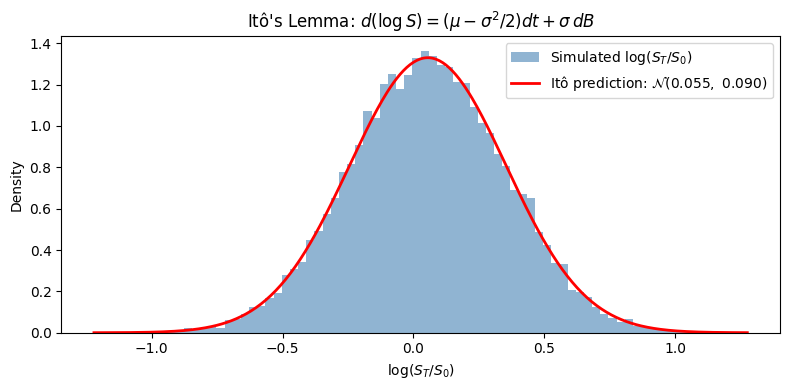

In [16]:
"""
Verify Ito's lemma numerically:
Under GBM, d(log S) = (mu - sigma^2/2)*dt + sigma*dB.
We simulate S via the SDE dS = mu*S*dt + sigma*S*dB,
then compare the empirical mean and variance of log(S_T/S_0)
against the Ito prediction.
"""
np.random.seed(99)

mu_i, sigma_i, S0_i, T_i = 0.10, 0.30, 100.0, 1.0
n_i = 1000
dt_i = T_i / n_i
Np_i = 20000

# Euler-Maruyama discretisation of dS = mu*S*dt + sigma*S*dB
S = np.full(Np_i, S0_i, dtype=float)
for _ in range(n_i):
    dW_i = np.sqrt(dt_i) * np.random.randn(Np_i)
    S = S + mu_i * S * dt_i + sigma_i * S * dW_i

log_ret = np.log(S / S0_i)

# Ito predictions
ito_mean = (mu_i - 0.5 * sigma_i**2) * T_i
ito_var  = sigma_i**2 * T_i

print("=== Verifying Ito's Lemma for d(log S) ===")
print(f"Predicted mean  (μ - σ²/2)·T = {ito_mean:.4f}")
print(f"Simulated mean               = {np.mean(log_ret):.4f}")
print()
print(f"Predicted variance  σ²·T     = {ito_var:.4f}")
print(f"Simulated variance           = {np.var(log_ret):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_ret, bins=80, density=True, alpha=0.6, color='steelblue', label='Simulated $\\log(S_T/S_0)$')
x = np.linspace(log_ret.min(), log_ret.max(), 400)
ax.plot(x, (1/(np.sqrt(ito_var)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-ito_mean)/np.sqrt(ito_var))**2),
        'r-', linewidth=2, label=f"Itô prediction: $\\mathcal{{N}}({ito_mean:.3f},\\ {ito_var:.3f})$")
ax.set(title="Itô's Lemma: $d(\\log S) = (\\mu - \\sigma^2/2)dt + \\sigma\\,dB$",
       xlabel='$\\log(S_T/S_0)$', ylabel='Density')
ax.legend()
plt.tight_layout()
plt.show()

## 6. A Zoo of Itô Processes

An **Itô process** is any stochastic process of the form:

$$dX_t = a(X_t, t)\, dt + b(X_t, t)\, dB_t$$

where $a$ (the **drift**) and $b$ (the **diffusion coefficient**) may depend on the current state $X_t$ and time $t$. Different choices of $a$ and $b$ generate the classic models of quantitative finance.

---

### 6.1 Brownian Motion with Drift

$$dS_t = \mu\, dt + \sigma\, dB_t \qquad \Rightarrow \qquad S_T = S_0 + \mu T + \sigma(B_T - B_0)$$

- The simplest Itô process. Drift $a = \mu$, diffusion $b = \sigma$ are constants.
- **Drawback:** Admits negative values (since it's just a shifted Brownian motion). Not a good model for stock prices but fine for log-prices or interest rates in certain regimes.

---

### 6.2 Geometric Brownian Motion (GBM)

$$\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dB_t \qquad \Rightarrow \qquad S_T = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma B_T\right]$$

- Drift $a = \mu S$, diffusion $b = \sigma S$ — both scale with the current price.
- **Always positive** (the exponential can never be zero).
- **Drawback:** Drift and variance go to zero as $S \to 0$ (no bankruptcy in the model), and returns are log-normally distributed with a fixed volatility (empirically, this is violated — volatility smiles).

---

### 6.3 Ornstein–Uhlenbeck (OU) Process

$$dS_t = \lambda(\bar{S} - S_t)\, dt + \sigma\, dB_t$$

- The **mean-reverting** process. When $S_t > \bar{S}$, the drift is negative (pulls down); when $S_t < \bar{S}$, the drift is positive (pulls up).
- $\lambda > 0$ is the **speed of mean reversion**; $\bar{S}$ is the **long-run mean**.
- The stationary distribution is $\mathcal{N}(\bar{S},\, \sigma^2 / 2\lambda)$.
- Used to model: **interest rates**, **volatility** (Heston model), **log price-spreads** in pairs trading.

---

### 6.4 Cox–Ingersoll–Ross (CIR) Process

$$d\rho_t = \lambda(\bar{\rho} - \rho_t)\, dt + \sigma\sqrt{\rho_t}\, dB_t$$

- Like OU but the diffusion scales with $\sqrt{\rho_t}$, which **prevents the process from going negative** (for $2\lambda\bar{\rho} > \sigma^2$, the Feller condition).
- As $\rho \to 0$, the drift pulls the process back up but the diffusion vanishes — it can't cross zero.
- Used to model **interest rates** (CIR model) and **stochastic variance** (Heston model).

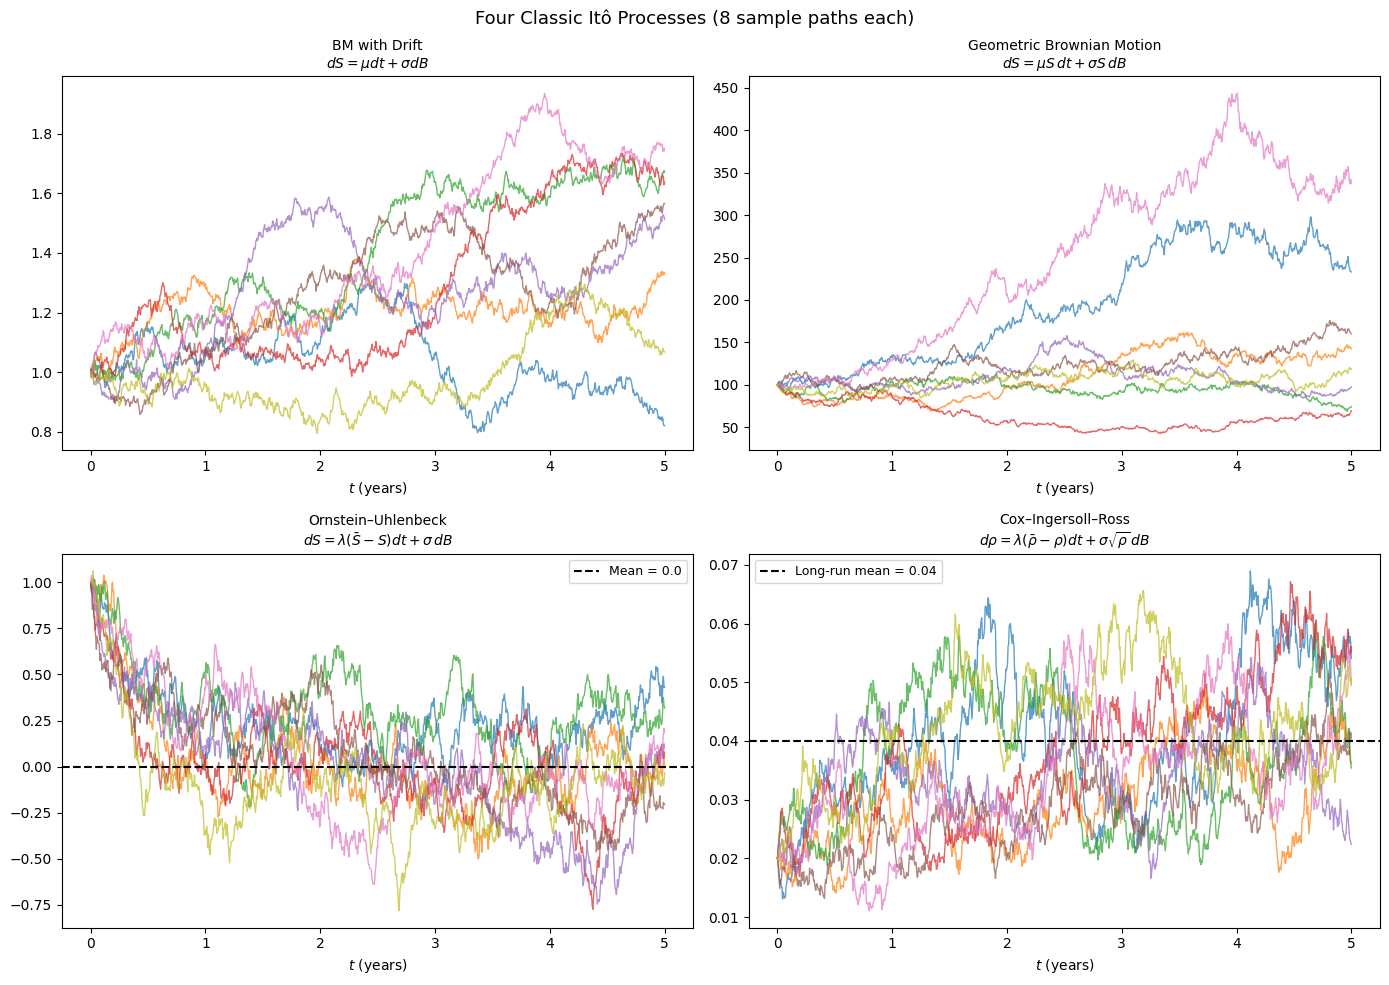

In [14]:
"""
Simulate and compare the four Ito processes side by side.
"""
np.random.seed(21)

T_p, n_p, Np_p = 5.0, 1000, 8
dt_p = T_p / n_p
t_p = np.linspace(0, T_p, n_p + 1)

# Parameters
mu_bm, sigma_bm = 0.05, 0.15
S0_bm = 1.0

mu_gbm, sigma_gbm = 0.06, 0.20
S0_gbm = 100.0

lam_ou, S_bar_ou, sigma_ou = 2.0, 0.0, 0.5
S0_ou = 1.0

lam_cir, rho_bar, sigma_cir = 1.5, 0.04, 0.10
rho0_cir = 0.02

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 0.8, Np_p))

for ax, (label, a_fn, b_fn, x0) in zip(axes_flat, [
    ("BM with Drift\n$dS = \\mu dt + \\sigma dB$",
     lambda x: mu_bm, lambda x: sigma_bm, S0_bm),
    ("Geometric Brownian Motion\n$dS = \\mu S\\,dt + \\sigma S\\,dB$",
     lambda x: mu_gbm * x, lambda x: sigma_gbm * x, S0_gbm),
    ("Ornstein–Uhlenbeck\n$dS = \\lambda(\\bar{S}-S)dt + \\sigma\\,dB$",
     lambda x: lam_ou * (S_bar_ou - x), lambda x: sigma_ou, S0_ou),
    ("Cox–Ingersoll–Ross\n$d\\rho = \\lambda(\\bar{\\rho}-\\rho)dt + \\sigma\\sqrt{\\rho}\\,dB$",
     lambda x: lam_cir * (rho_bar - x), lambda x: sigma_cir * np.sqrt(np.maximum(x, 0)), rho0_cir),
]):
    for i, c in enumerate(colors):
        X = np.zeros(n_p + 1)
        X[0] = x0
        z = np.random.randn(n_p)
        for t in range(n_p):
            X[t+1] = X[t] + a_fn(X[t]) * dt_p + b_fn(X[t]) * np.sqrt(dt_p) * z[t]
        ax.plot(t_p, X, alpha=0.7, linewidth=1.0, color=c)

    ax.set_title(label, fontsize=10)
    ax.set_xlabel('$t$ (years)')

axes_flat[2].axhline(S_bar_ou, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {S_bar_ou}')
axes_flat[2].legend(fontsize=9)
axes_flat[3].axhline(rho_bar, color='black', linestyle='--', linewidth=1.5, label=f'Long-run mean = {rho_bar}')
axes_flat[3].legend(fontsize=9)

plt.suptitle('Four Classic Itô Processes (8 sample paths each)', fontsize=13)
plt.tight_layout()
plt.show()


## 7. From SDE to PDE: The Black-Scholes Equation

### The Setup

We want to price a **derivative security** $V(t, S_t)$ — whose value depends on the current time $t$ and the stock price $S_t$, which follows GBM:

$$dS_t = \mu S_t\, dt + \sigma S_t\, dB_t$$

Applying Itô's Lemma to $V(t, S)$:

$$dV = \left(\frac{\partial V}{\partial t} + \frac{(\sigma S)^2}{2}\frac{\partial^2 V}{\partial S^2}\right) dt + \frac{\partial V}{\partial S}\, dS$$

### The Delta-Hedging Argument

Construct a **portfolio** $\pi$ that is long the derivative and short $\Delta$ shares of the stock:

$$\pi \equiv V - \Delta S, \quad \Delta \text{ constant over } dt$$

The portfolio's change is:

$$d\pi = dV - \Delta\, dS = \left(\frac{\partial V}{\partial t} + \frac{(\sigma S)^2}{2}\frac{\partial^2 V}{\partial S^2}\right) dt + \left(\frac{\partial V}{\partial S} - \Delta\right) dS$$

The **stochastic term** (the $dS$ part) can be **completely eliminated** by choosing:

$$\boxed{\Delta = \frac{\partial V}{\partial S}}$$

This is the **delta hedge**: hold $\partial V / \partial S$ shares for every unit of the derivative. With this choice:

$$d\pi = \left(\frac{\partial V}{\partial t} + \frac{\sigma^2 S^2}{2}\frac{\partial^2 V}{\partial S^2}\right) dt$$

The portfolio is **risk-free** — it contains no Brownian term.

> **Why does delta change over time?** Because $\partial V/\partial S$ depends on $S_t$ and $t$, both of which evolve. The hedger must continuously rebalance, which is why this is called **dynamic delta hedging**.

### No-Arbitrage Pricing

Since $\pi$ is risk-free, it must earn the risk-free rate $r$ (otherwise there would be an arbitrage):

$$d\pi = r\pi\, dt = r(V - \Delta S)\, dt = \left(rV - rS\frac{\partial V}{\partial S}\right) dt$$

Equating the two expressions for $d\pi$:

$$\frac{\partial V}{\partial t} + \frac{\sigma^2 S^2}{2}\frac{\partial^2 V}{\partial S^2} = rV - rS\frac{\partial V}{\partial S}$$

Rearranging gives the celebrated **Black-Scholes PDE**:

$$\boxed{\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{\sigma^2 S^2}{2}\frac{\partial^2 V}{\partial S^2} - rV = 0}$$

### Key Observations

1. **$\mu$ disappeared.** The drift of the stock is absent from the equation! This is profound: the price of any derivative is independent of the expected return of the underlying asset. Two investors with different views on $\mu$ must agree on the option price.

2. **Explicit parameters:** only $\sigma$ (volatility) and $r$ (risk-free rate).

3. **Boundary conditions** encode the contract type:
   - European call: $V(T, S) = \max(S - K, 0)$
   - European put: $V(T, S) = \max(K - S, 0)$

4. **The PDE is linear** in $V$, so the sum of two solutions is also a solution (put-call parity follows immediately).

### Connection to Monte Carlo (Risk-Neutral Pricing)

The Black-Scholes PDE is equivalent to computing the discounted expectation under the **risk-neutral measure** $\mathbb{Q}$ (where $\mu$ is replaced by $r$):

$$V(0) = e^{-rT} \mathbb{E}^{\mathbb{Q}}[V(T)]$$

This is the **Feynman-Kac formula** — a bridge between PDEs and expectations that underpins all of Monte Carlo option pricing.

                       Analytic         MC
---------------------------------------------
          Call price    10.4506    10.4036
           Put price     5.5735     5.5838


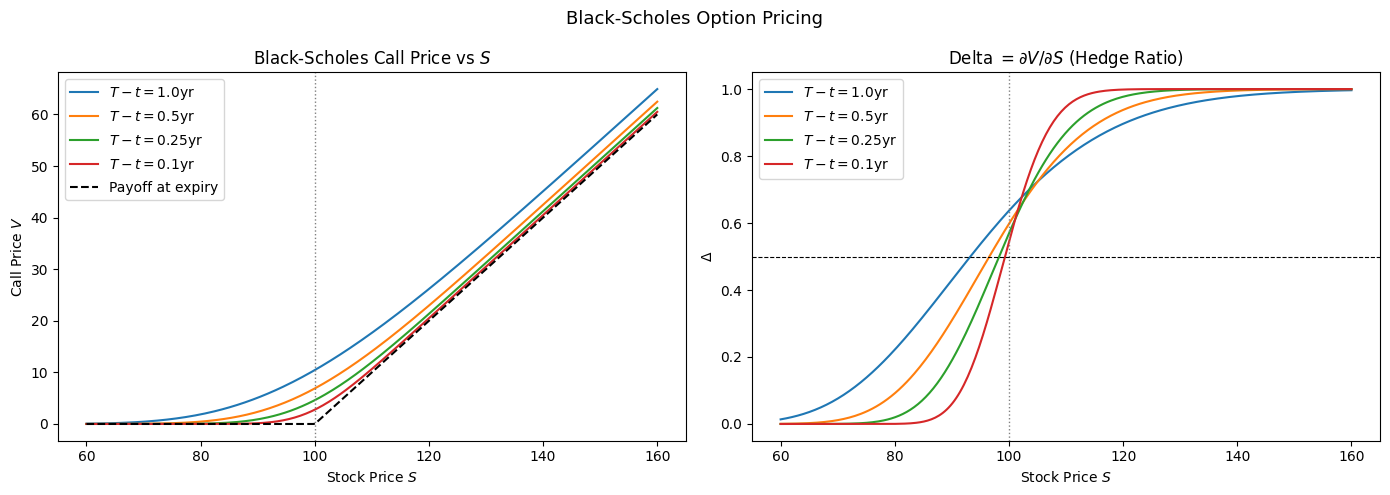

In [12]:
"""
Black-Scholes formula vs. Monte Carlo pricing.
We price a European call option both analytically (Black-Scholes)
and via risk-neutral Monte Carlo simulation, and verify they match.
"""
from scipy.stats import norm

def bs_call(S, K, T, r, sigma):
    """Analytical Black-Scholes call price."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    """Analytical Black-Scholes put price (via put-call parity)."""
    return bs_call(S, K, T, r, sigma) - S + K * np.exp(-r * T)

# Option parameters
S0_bs, K_bs, T_bs, r_bs, sigma_bs = 100, 100, 1.0, 0.05, 0.20

# Analytical prices
call_an = bs_call(S0_bs, K_bs, T_bs, r_bs, sigma_bs)
put_an  = bs_put(S0_bs, K_bs, T_bs, r_bs, sigma_bs)

# Monte Carlo under RISK-NEUTRAL measure (mu = r)
np.random.seed(42)
Np_bs = 200_000
n_bs  = 252
dt_bs = T_bs / n_bs

dlog_bs = (r_bs - 0.5*sigma_bs**2)*dt_bs + sigma_bs*np.sqrt(dt_bs)*np.random.randn(n_bs, Np_bs)
S_T_bs  = S0_bs * np.exp(dlog_bs.sum(axis=0))

call_mc = np.exp(-r_bs * T_bs) * np.mean(np.maximum(S_T_bs - K_bs, 0))
put_mc  = np.exp(-r_bs * T_bs) * np.mean(np.maximum(K_bs - S_T_bs, 0))

print("=" * 45)
print(f"{'':>20} {'Analytic':>10} {'MC':>10}")
print("-" * 45)
print(f"{'Call price':>20} {call_an:>10.4f} {call_mc:>10.4f}")
print(f"{'Put price':>20} {put_an:>10.4f} {put_mc:>10.4f}")
print("=" * 45)

# Visualise call price as a function of S (the option's value surface)
S_range = np.linspace(60, 160, 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

times_to_maturity = [1.0, 0.5, 0.25, 0.1]
for tau in times_to_maturity:
    axes[0].plot(S_range, bs_call(S_range, K_bs, tau, r_bs, sigma_bs),
                 label=f'$T-t={tau}$yr')
axes[0].plot(S_range, np.maximum(S_range - K_bs, 0), 'k--', linewidth=1.5, label='Payoff at expiry')
axes[0].axvline(K_bs, color='gray', linestyle=':', linewidth=1)
axes[0].set(title='Black-Scholes Call Price vs $S$', xlabel='Stock Price $S$', ylabel='Call Price $V$')
axes[0].legend()

# Delta = dV/dS
for tau in times_to_maturity:
    d1 = (np.log(S_range/K_bs) + (r_bs + 0.5*sigma_bs**2)*tau) / (sigma_bs*np.sqrt(tau))
    axes[1].plot(S_range, norm.cdf(d1), label=f'$T-t={tau}$yr')
axes[1].axvline(K_bs, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].set(title='Delta $= \\partial V/\\partial S$ (Hedge Ratio)',
            xlabel='Stock Price $S$', ylabel='$\\Delta$')
axes[1].legend()

plt.suptitle('Black-Scholes Option Pricing', fontsize=13)
plt.tight_layout()
plt.show()

## Summary: The Conceptual Chain

$$\underbrace{\text{IID shocks } z_t}_{\text{discrete, unit size}} \xrightarrow{\epsilon_t = \sqrt{\Delta t}\,z_t} \underbrace{dB_t \sim \mathcal{N}(0, dt)}_{\text{Brownian increment}} \xrightarrow{\text{Itô's Lemma}} \underbrace{dF = \cdots + \tfrac{b^2}{2}F'' dt}_{\text{stochastic chain rule}} \xrightarrow{\Delta\text{-hedge}} \underbrace{\text{Black-Scholes PDE}}_{\text{option pricing}}$$

| Step | Key Formula | Insight |
|---|---|---|
| Scaling | $\epsilon_t = \sqrt{\Delta t}\, z_t$ | Only choice giving finite variance in the limit |
| Brownian Motion | $W_t - W_s \sim \mathcal{N}(0, t-s)$ | Continuous, nowhere differentiable |
| Itô's Lemma | $dF = F_t\,dt + F_S\,dS + \tfrac{1}{2}F_{SS}\,b^2\,dt$ | Extra $b^2/2 F_{SS}$ term vs ordinary calculus |
| GBM solution | $S_T = S_0 e^{(\mu - \sigma^2/2)T + \sigma B_T}$ | Lognormal prices, always positive |
| Black-Scholes | $V_t + rS V_S + \tfrac{\sigma^2 S^2}{2} V_{SS} - rV = 0$ | $\mu$ vanishes — risk-neutral pricing |
| Monte Carlo | $V(0) = e^{-rT}\mathbb{E}^{\mathbb{Q}}[V(T)]$ | Equivalent PDE ↔ expectation under $\mathbb{Q}$ |